In [3]:
import pandas
import numpy
import sklearn
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
import yfinance
import matplotlib.pyplot
import requests
from datetime import datetime
from dateutil.relativedelta import relativedelta
import warnings
warnings.filterwarnings(action='ignore')

In [155]:
temp_data=pandas.read_csv('/Users/kbh/Downloads/lending club/all_clean_current_final_out_data.csv')

In [156]:
temp_data=pandas.read_csv('/Users/kbh/Downloads/lending club/all_clean_current_final_out_data.csv')


y_temp=temp_data['total_rec_prncp']/temp_data['funded_amnt']


def clean_data(x) :
    x.replace([numpy.inf],0,inplace=True)
    x.replace([numpy.NAN],0,inplace=True)

clean_data(y_temp)

temp_data.drop('id',axis=1,inplace=True)
select_feature='''
loan_amnt
term
int_rate
installment
sub_grade
emp_length
home_ownership
annual_inc
verification_status
purpose
dti
delinq_2yrs
fico_range_high
mths_since_last_delinq
open_acc
pub_rec
revol_util
total_acc
initial_list_status
last_fico_range_high
collections_12_mths_ex_med
mths_since_last_major_derog
application_type
annual_inc_joint
dti_joint
verification_status_joint
acc_now_delinq
tot_cur_bal
open_acc_6m
open_act_il
open_il_12m
open_il_24m
mths_since_rcnt_il
total_bal_il
il_util
open_rv_12m
max_bal_bc
all_util
total_rev_hi_lim
total_cu_tl
inq_last_12m
acc_open_past_24mths
avg_cur_bal
bc_open_to_buy
bc_util
chargeoff_within_12_mths
delinq_amnt
mo_sin_old_il_acct
mo_sin_old_rev_tl_op
mo_sin_rcnt_rev_tl_op
mo_sin_rcnt_tl
mort_acc
mths_since_recent_bc
mths_since_recent_bc_dlq
mths_since_recent_inq
mths_since_recent_revol_delinq
num_accts_ever_120_pd
num_actv_bc_tl
num_actv_rev_tl
num_bc_sats
num_bc_tl
num_il_tl
num_op_rev_tl
num_rev_accts
num_rev_tl_bal_gt_0
num_sats
num_tl_90g_dpd_24m
num_tl_op_past_12m
pct_tl_nvr_dlq
percent_bc_gt_75
pub_rec_bankruptcies
tax_liens
tot_hi_cred_lim
total_bal_ex_mort
total_bc_limit
total_il_high_credit_limit
revol_bal_joint
sec_app_fico_range_low
sec_app_fico_range_high
sec_app_inq_last_6mths
sec_app_mort_acc
sec_app_open_acc
sec_app_revol_util
sec_app_open_act_il
sec_app_num_rev_accts
sec_app_collections_12_mths_ex_med
'''
select_feature=select_feature.strip().split('\n')
x_temp=temp_data[select_feature].reset_index(drop=True)
x_temp['bar_ex_mort_year']=x_temp.total_bal_ex_mort/x_temp.annual_inc
x_temp['bar_il_year']=x_temp.total_bal_il/x_temp.annual_inc
x_temp['loan_year']=x_temp.loan_amnt/x_temp.annual_inc
clean_data(x_temp)

In [20]:
def splitset(x,y) :
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
    x_train, x_valid, y_train, y_valid = train_test_split(x_train, y_train, test_size=0.25, random_state=42)
    return x_train.reset_index(drop=True),\
        y_train.reset_index(drop=True),\
        x_valid.reset_index(drop=True),\
        y_valid.reset_index(drop=True),\
        x_test.reset_index(drop=True),\
        y_test.reset_index(drop=True)

bx_train,y_train,bx_valid, y_valid,bx_test,y_test=splitset(x_temp,y_temp)

## scaling, encoding
def onehot_train_valid(x_train,x_valid) :
    one=OneHotEncoder()
    temp_final=pandas.DataFrame()
    temp_valid_final=pandas.DataFrame()
    temp_data=x_train.select_dtypes(include='object')
    temp_data2=x_valid.select_dtypes(include='object')
    for i in range(0,len(temp_data.columns)):
        one.fit(temp_data.iloc[:,i].values.reshape(-1,1))
        temp_x=one.transform(temp_data.iloc[:,i].values.reshape(-1,1)).toarray().astype(int)
        temp_x=pandas.DataFrame(temp_x,
                            columns=[str(one.categories_[0][i]) for i in
                                     range(len(one.categories_[0]))
                            ]
                            )
        temp_x_valid = one.transform(temp_data2.iloc[:, i].values.reshape(-1, 1)).toarray().astype(int)
        temp_x_valid = pandas.DataFrame(temp_x_valid,
                              columns=[str(one.categories_[0][i]) for i in
                                       range(len(one.categories_[0]))
                                       ]
                              )

        temp_final=pandas.concat([temp_x,temp_final],axis=1)
        temp_valid_final=pandas.concat([temp_x_valid,temp_valid_final],axis=1)
    return temp_final.reset_index(drop=True), temp_valid_final.reset_index(drop=True)

def stsc_train_valid(x_train,x_valid) :
    stdsc=StandardScaler()
    temp_x=x_train.select_dtypes(exclude='object')
    temp_valid=x_valid.select_dtypes(exclude='object')
    name=temp_x.columns
    stdsc.fit(numpy.array(temp_x).reshape(-1,len(name)))
    temp_x = stdsc.transform(numpy.array(temp_x).reshape(-1, len(name)))
    temp_x=pandas.DataFrame(temp_x)
    temp_x.columns=name
    temp_x_valid=stdsc.transform(numpy.array(temp_valid).reshape(-1,len(name)))
    temp_x_valid=pandas.DataFrame(temp_x_valid)
    temp_x_valid.columns=name

    return temp_x.reset_index(drop=True), temp_x_valid.reset_index(drop=True)

one_train,one_valid=onehot_train_valid(x_train=bx_train,x_valid=bx_valid)
stsc_train,stsc_valid=stsc_train_valid(bx_train,bx_valid)

x_train=pandas.concat([stsc_train,one_train],axis=1)
x_valid=pandas.concat([stsc_valid,one_valid],axis=1)

x_train_np=numpy.array(x_train)
x_valid_np=numpy.array(x_valid)

In [27]:
xgb_model = XGBRegressor(
    random_state=101,
    objective='reg:absoluteerror',
    n_estimators=300,
    min_child_weight=17,
    max_depth=15,
    learning_rate=0.05,
    gamma=1,
    colsample_bytree=1.0
)
xgb_model.fit(x_train_np, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=1.0, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=1, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.05, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=15, max_leaves=None,
             min_child_weight=17, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=300, n_jobs=None,
             num_parallel_tree=None, objective='reg:absoluteerror', ...)

In [43]:
y_pred = xgb_model.predict(x_valid_np)
y_pred=numpy.where(y_pred>=1,1,y_pred)
y_pred=numpy.where(y_pred<=0,0,y_pred)
mae = mean_absolute_error(y_valid, y_pred)
print(f"Mean Absolute Error: {mae:.4f}")

Mean Absolute Error: 0.0914


In [47]:
import shap

In [52]:
explainer = shap.TreeExplainer(xgb_model,x_train)
shap_values=explainer.shap_values(x_valid)
feature_names=x_train.columns.tolist()

100%|===================| 218736/218752 [121:31<00:00]        

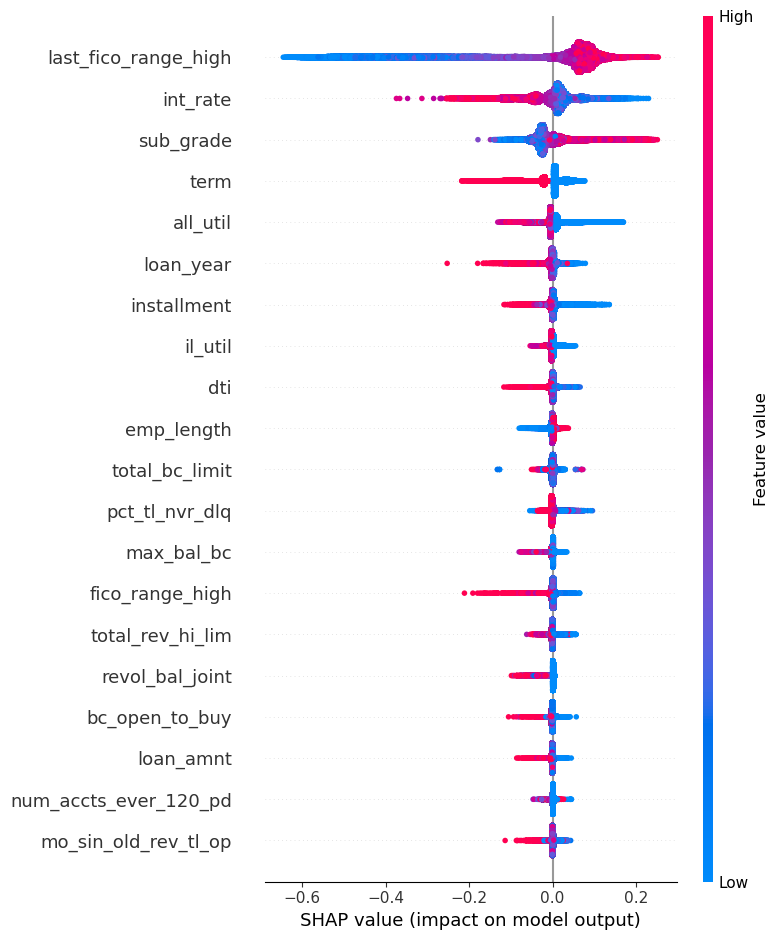

In [53]:
shap.summary_plot(shap_values, x_valid, feature_names=feature_names)

In [69]:
# matplotlib.pyplot.savefig('/Users/kbh/Downloads/lending club/shap_summary_plot.png', bbox_inches='tight',dpi=400)

<Figure size 640x480 with 0 Axes>

In [59]:
shap_data_frame = pandas.DataFrame(shap_values, columns=x_train.columns)

In [61]:
# shap_data_frame.to_csv('/Users/kbh/Downloads/lending club/xgb_shap_value.csv',index=False)

# Calc rate

In [71]:
def stsc(x) :
    stdsc=StandardScaler()
    temp_x=x.select_dtypes(exclude='object')
    name=temp_x.columns
    stdsc.fit(numpy.array(temp_x).reshape(-1,len(name)))
    temp_x = stdsc.transform(numpy.array(temp_x).reshape(-1, len(name)))
    temp_x=pandas.DataFrame(temp_x)
    temp_x.columns=name
    temp_x=temp_x.reset_index(drop=True)
    return temp_x

def onehot(x):
	one = OneHotEncoder()
	temp_data = x.select_dtypes(include='object')
	temp_final = pandas.DataFrame()

	for col in temp_data.columns:
		one.fit(temp_data[col].values.reshape(-1,1))

		col_df = pandas.DataFrame(one.transform(temp_data[col].values.reshape(-1,1)).toarray().astype(int), columns=one.get_feature_names_out([col]))
		temp_final = pandas.concat([temp_final, col_df], axis=1)
		temp_final=temp_final.reset_index(drop=True)
	return temp_final

one_train=onehot(x_temp)
stsc_train=stsc(x_temp)
x_real=pandas.concat([stsc_train,one_train],axis=1)

In [72]:
y_real_pred=xgb_model.predict(x_real)
y_real_pred=numpy.where(y_real_pred>=1,1,y_real_pred)
y_real_pred=numpy.where(y_real_pred<=0,0,y_real_pred)

In [129]:
target_result=pandas.DataFrame(y_real_pred,columns=['target'])

In [135]:
final_xgb_rate=pandas.concat([temp_data,target_result],axis=1)

In [87]:
def calc_etf_rate(loan_data, etf_data):
    loans = loan_data[['issue_d','term']]
    loans['issue_d'] = pandas.to_datetime(loans['issue_d'])
    
    loans['etf_start_day'] = numpy.where(
        loans['term'] == 36,
        loans['issue_d'] - pandas.DateOffset(years=3),
        loans['issue_d'] - pandas.DateOffset(years=5)
    )
    loans['etf_end_day'] = loans['issue_d']
    
    # ETF 수익률을 계산할 열 추가
    loans['etf_rate'] = 0.0

    # 각 대출에 대해 수익률 계산
    for i, row in loans.iterrows():
        etf_start_day = row['etf_start_day']
        etf_end_day = row['etf_end_day']
        revenue_data = etf_data[(etf_data['month'] >= etf_start_day) & (etf_data['month'] <= etf_end_day)]
        
        if not revenue_data.empty:
            open_price = revenue_data.iloc[0]['Open']
            close_price = revenue_data.iloc[-1]['Close']
            dividends_sum = revenue_data['Dividends'].sum()
            capital_gains_sum = revenue_data['Capital Gains'].sum()
            year_revenue = dividends_sum + capital_gains_sum + (close_price - open_price)
            etf_rate = year_revenue / open_price
            loans.at[i, 'etf_rate'] = etf_rate
    
    return loans

In [89]:
def calc_bond_rate(loan_data, bond3yr, bond5yr):
    loans = loan_data[['issue_d','term']]
    loans['issue_d'] = pandas.to_datetime(loans['issue_d'])  # issue_d를 datetime 형식으로 변환

    # 3년 또는 5년 채권에 따라 수익률을 결정하기 위한 기준 데이터프레임 병합
    bond3yr['date'] = pandas.to_datetime(bond3yr['date'])
    bond5yr['date'] = pandas.to_datetime(bond5yr['date'])

    # 3년과 5년 채권 데이터를 loan_data와 결합
    loans_3yr = pandas.merge(loans, bond3yr[['date', 'rate']], left_on='issue_d', right_on='date', how='left', suffixes=('', '_3yr'))
    loans_5yr = pandas.merge(loans, bond5yr[['date', 'rate']], left_on='issue_d', right_on='date', how='left', suffixes=('', '_5yr'))

    # 대출 기간에 따라 3년 또는 5년 채권 수익률을 선택
    loans['bond_rate'] = numpy.where(
        loans['term'] == 36,  # 조건: 3년 대출
        loans_3yr['rate'],  # 3년 채권 수익률 선택
        loans_5yr['rate']  # 5년 채권 수익률 선택
    )

    # 수익률 계산: (1 + rate / 100)
    loans['bond_rate'] = 1 + loans['bond_rate'] / 100

    return loans[['bond_rate']]

In [91]:
def selected_etf_bond_rate(loan_data, etf_data, bond3yr, bond5yr):
    # ETF 수익률 계산
    loans_with_etf_rate = calc_etf_rate(loan_data, etf_data)

    # 채권 수익률 계산
    loans_with_bond_rate = calc_bond_rate(loan_data, bond3yr, bond5yr)
    loans = loans_with_etf_rate.copy()
    loans['bond_rate'] = loans_with_bond_rate['bond_rate']

    # ETF 수익률과 채권 수익률 중 더 큰 값을 선택
    loans['selected_type'] = numpy.where(
        loans['etf_rate'] > loans['bond_rate'],
        'ETF',
        'Bond'
    )
    loans['selected_rate'] = numpy.where(
        loans['etf_rate'] > loans['bond_rate'],
        loans['etf_rate'],
        loans['bond_rate']
    )

    # 최종 결과 DataFrame 생성
    result = loans[['selected_type', 'selected_rate']].rename(columns={'selected_type': 'type', 'selected_rate': 'rate'})
    result = result.reset_index(drop=True)
    return result

In [93]:
def loan_rate(temp_data):
    loan_revenue=((temp_data['installment']*temp_data['term']-temp_data['funded_amnt'])+temp_data['target']*temp_data['funded_amnt'])/temp_data['funded_amnt']
    return loan_revenue

In [198]:
def select_good_rate(loan_data) : 
    loans=loan_data
    loans['final_type'] = numpy.where(
        loans['loan_rate'] > loans['rate'],
        'Loan',
        loans['type']
    )
    loans['selected_rate'] = numpy.where(
        loans['loan_rate'] > loans['rate'],
        loans['loan_rate'],
        loans['rate']
    )
    loans=loans.reset_index(drop=True)
    return loans

In [107]:
# ITE ETF 데이터를 다운로드
ticker = 'SHY'
ite = yfinance.Ticker(ticker)

# 2004년부터 현재까지의 배당금 정보
dividends = ite.dividends['2004-01-01':]

# 2007년부터 현재까지의 가격 데이터 다운로드
etf_data = ite.history(start="2004-01-01")
etf_data['month']=pandas.to_datetime(etf_data.index.strftime('%Y-%m-%d'))
# 모든 열 출력 설정
pandas.set_option('display.max_columns', None)

# 모든 행 출력 설정
pandas.set_option('display.max_rows', None)

In [105]:
api_key = 'ca552aba80a8399206569337091186c9'

# FRED에서 3년 및 5년 만기 미국 국채 수익률 데이터 가져오기
def fetch_fred_data(series_id, api_key, start_date, end_date):
    url = f'https://api.stlouisfed.org/fred/series/observations'
    params = {
        'series_id': series_id,
        'api_key': api_key,
        'file_type': 'json',
        'observation_start': start_date,
        'observation_end': end_date
    }
    response = requests.get(url, params=params)
    data = response.json()
    df = pandas.DataFrame(data['observations'])
    df['date'] = pandas.to_datetime(df['date'])
    
    # "."을 NaN으로 변경하고 숫자로 변환
    df['value'] = df['value'].replace('.', pandas.NA)
    df['rate'] = pandas.to_numeric(df['value'], errors='coerce')  # 에러 발생시 NaN으로 대체
    
    return df

# 데이터 가져오기
start_date = '2006-12-30'
end_date = '2020-12-31'

# 3년 만기 미국 국채 수익률
temp_bond3yr = fetch_fred_data('DGS3', api_key, start_date, end_date)
temp_bond3yr['rate']=temp_bond3yr['rate'].ffill()
# 5년 만기 미국 국채 수익률
temp_bond5yr = fetch_fred_data('DGS5', api_key, start_date, end_date)
temp_bond5yr['rate']=temp_bond5yr['rate'].ffill()

In [109]:
temp_bond5yr.drop(['realtime_start','realtime_end','value'],inplace=True,axis=1)

full_date_range = pandas.date_range(start=temp_bond5yr['date'].min(), end=temp_bond5yr['date'].max())

df_full = pandas.DataFrame({'date': full_date_range})
bond5yr = pandas.DataFrame(pandas.merge(df_full, temp_bond5yr, on='date', how='left'))
bond5yr['date']=bond5yr['date'].dt.strftime('%Y-%m-%d')
# 결측값을 이전 값으로 채우기
bond5yr.ffill(inplace=True)
bond5yr.bfill(inplace=True)

In [111]:
temp_bond3yr.drop(['realtime_start','realtime_end','value'],inplace=True,axis=1)

full_date_range = pandas.date_range(start=temp_bond3yr['date'].min(), end=temp_bond3yr['date'].max())

df_full = pandas.DataFrame({'date': full_date_range})
bond3yr = pandas.merge(df_full, temp_bond3yr, on='date', how='left')
bond3yr['date']=bond3yr['date'].dt.strftime('%Y-%m-%d')
# 결측값을 이전 값으로 채우기
bond3yr.ffill(inplace=True)
bond3yr.bfill(inplace=True)

In [139]:
temp_data['loan_rate']=loan_rate(final_xgb_rate)

In [184]:
# etf_bond_result=selected_etf_bond_rate(temp_data,etf_data,bond3yr,bond5yr)
loan_data=pandas.concat([temp_data,etf_bond_result],axis=1)


0    1.127640
1    1.069908
2    0.629422
3    1.168800
4    1.161450
Name: loan_rate, dtype: float64

In [204]:
final_data=select_good_rate(loan_data)

In [36]:
final_data['rate'].mean()

NameError: name 'final_data' is not defined

In [210]:
pandas.set_option('display.float_format', '{:.4f}'.format)

In [230]:
# final_data.to_csv('/Users/kbh/Downloads/lending club/xgboost_predcit_rate_full.csv',index=False)

In [224]:
# real_final_xgboost=final_data[['loan_rate','final_type','selected_rate']].head()

In [226]:
# real_final_xgboost.to_csv('/Users/kbh/Downloads/lending club/xgboost_predcit_rate.csv',index=False)

In [40]:
xgre=pandas.read_csv('/Users/kbh/Downloads/lending club/xgboost_predcit_rate_full.csv')

In [15]:
xgre.head()

,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,sub_grade,emp_length,home_ownership,annual_inc,...,sec_app_open_act_il,sec_app_num_rev_accts,sec_app_chargeoff_within_12_mths,sec_app_collections_12_mths_ex_med,debt_settlement_flag,loan_rate,type,rate,final_type,selected_rate
0,6000.0,6000.0,6000.0,36,7.97,187.94,4,2.0,MORTGAGE,45000.0,...,10.0,4.0,1.0,0.0,N,1.127640,Bond,1.0190,Loan,1.127640
1,23200.0,23200.0,23200.0,60,24.99,680.82,23,10.0,MORTGAGE,110000.0,...,0.0,0.0,0.0,0.0,Y,1.069908,Bond,1.0100,Loan,1.069908
2,16000.0,16000.0,16000.0,36,7.07,494.55,1,0.0,MORTGAGE,65000.0,...,0.0,0.0,0.0,0.0,N,0.629422,Bond,1.0162,Bond,1.016200
3,4500.0,4500.0,4500.0,36,10.42,146.10,7,5.0,MORTGAGE,50000.0,...,0.0,0.0,0.0,0.0,N,1.168800,Bond,1.0148,Loan,1.168800
4,20000.0,20000.0,20000.0,36,9.99,645.25,7,10.0,MORTGAGE,60000.0,...,0.0,0.0,0.0,0.0,N,1.161450,Bond,1.0103,Loan,1.161450


In [13]:
xgre['selected_rate'].mean()

1.1950168887443704

In [23]:
import matplotlib.pyplot as plt

In [42]:
temp_data=pandas.read_csv('/Users/kbh/Downloads/lending club/DNN_final_rate.csv')

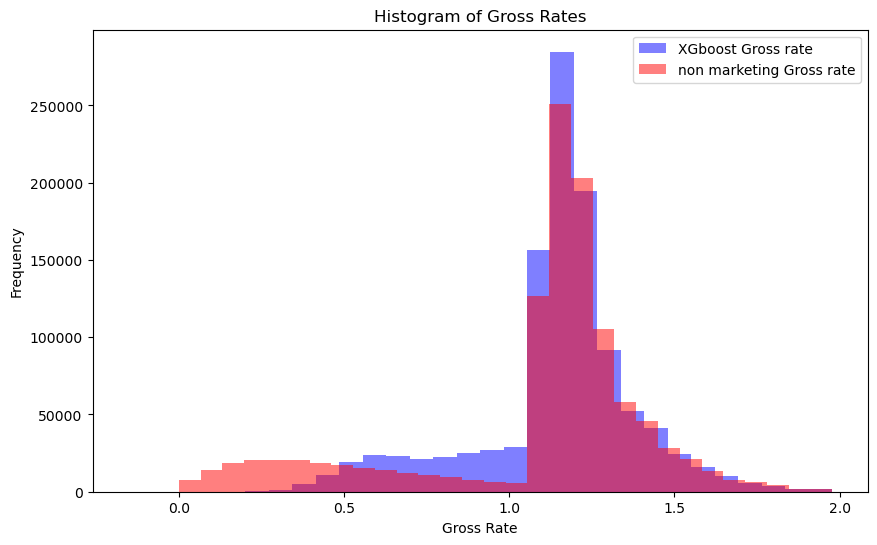

In [46]:
plt.close()
plt.ioff()
plt.figure(figsize=(10, 6))
plt.hist(xgre['loan_rate'], bins=30, alpha=0.5, label='XGboost Gross rate', color='blue')
plt.hist(temp_data['non_marketing_rate'], bins=30, alpha=0.5, label='non marketing Gross rate',color='red')

plt.title('Histogram of Gross Rates')
plt.xlabel('Gross Rate')
plt.ylabel('Frequency')

plt.legend()
# plt.savefig('/Users/kbh/Downloads/lending club/Histogram of XGboost predict.png',dpi=400)
plt.show()